In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub
!pip install -r requirements.txt

%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench
!pip install jedi
!python -m pip install -U pip setuptools wheel
!pip install -r requirements.txt
!pip install -e .

import sys

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
sys.path.insert(0, f"{BASE}/ForensicHub")
sys.path.insert(0, f"{BASE}/DeepfakeBench")
sys.path.insert(0, f"{BASE}/IMDLBenCo")

/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/ForensicHub
/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/DeepfakeBench
Obtaining file:///content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/DeepfakeBench
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for deepfakebench (pyproject.toml) ... done
  Created wheel for deepfakebench: filename=deepfakebench-0.1.0-0.editable-py3-none-any.whl size=14517 sha256=62951e4360b823e92325ce36b38898fad5506f0464f63802fce429a7ce24ade3
  Stored in directory: /tmp/pip-ephem-wheel-cache-ab1rr2p6/wheels/9f/69/83/09f777ca13410471b8e2a8431150d66b966538b5ec9615af42
Successfully built deepfakebench
  Attempting uninstall: deepfak

In [3]:
import os, glob, json

TEST_DIR = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/publictest_data"
TEST_REF = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/publictest_reference/reference.txt"
STAGING = "/content/DiffusionForensics_Recons"
os.makedirs(STAGING, exist_ok=True)

IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff")

# ═══════════════════════════════════════════════════
# TEST — publictest_data_final + reference.txt
# ═══════════════════════════════════════════════════
with open(TEST_REF) as f:
    test_labels = [int(line.strip()) for line in f if line.strip()]

test_images = sorted(glob.glob(os.path.join(TEST_DIR, "*.*")))
test_images = [
    p for p in test_images
    if os.path.splitext(p)[1].lower() in IMG_EXTS
]

assert len(test_images) == len(test_labels), (
    f"Mismatch: {len(test_images)} images vs {len(test_labels)} labels"
)

test_items = [
    {"path": p, "label": l}
    for p, l in zip(test_images, test_labels)
]

n_real = sum(1 for x in test_items if x["label"] == 0)
n_fake = sum(1 for x in test_items if x["label"] == 1)

print(f"TEST: {len(test_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# SAVE test.json only
# ═══════════════════════════════════════════════════
out = os.path.join(STAGING, "test.json")

with open(out, "w") as f:
    json.dump(test_items, f, indent=2)

print(f"\n✓ test.json → {len(test_items)} items → {out}")

TEST: 1000 images  (real=500, fake=500)

✓ test.json → 1000 items → /content/DiffusionForensics_Recons/test.json


In [ ]:
# import shutil
# from pathlib import Path

# CKPT_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/effort_3440_test")

# if CKPT_DIR.exists():
#     shutil.rmtree(CKPT_DIR)
#     print("🧹 Old checkpoints deleted")

# CKPT_DIR.mkdir(parents=True, exist_ok=True)
# print("✅ Fresh checkpoint directory created:", CKPT_DIR)

✅ Fresh checkpoint directory created: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/effort_3440_test


In [ ]:
# %cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub

# !PYTHONPATH=/content/drive/MyDrive/Capstone_Hripsime/Frameworks:$PWD \
# MASTER_ADDR=127.0.0.1 MASTER_PORT=29602 \
# python -m ForensicHub.training_scripts.test \
# --config "ForensicHub/statics/crossdataset_image/effort_3440val_test.yaml"

/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/ForensicHub
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2.10.0+cu128
Current Torch version: 2.10
/usr/local/lib/python3.12/dist-packages/timm/optim/optim_factory.py:7: FutureWarning: Importing from timm.optim.optim_factory is deprecated, please import via timm.optim
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.optim", FutureWarning)
2026-05-04 09:24:50.363100: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the app

In [4]:
import os
import json
import glob
import numpy as np
import torch
from PIL import Image
import sys

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"

sys.path.insert(0, BASE)
sys.path.insert(0, f"{BASE}/ForensicHub")
sys.path.insert(0, f"{BASE}/DeepfakeBench")
sys.path.insert(0, f"{BASE}/IMDLBenCo")

# Important: registers DeepfakeBench detectors such as EffortDetector
import ForensicHub.tasks.deepfake
from ForensicHub.registry import MODELS, build_from_registry


# =========================
# PATHS
# =========================
CHECKPOINT_DIR = f"{BASE}/ForensicHub/log/effort_3440_train"
LOG_PATH = os.path.join(CHECKPOINT_DIR, "log.txt")

TEST_JSON = "/content/DiffusionForensics_Recons/test.json"
OUT_RESULTS = "/content/DiffusionForensics_Recons/effort_test_3440val_inference_results.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = 0.5
IMAGE_SIZE = 224


# =========================
# FIND BEST CHECKPOINT BY VAL AUC
# =========================
def find_best_checkpoint_by_auc(checkpoint_dir, log_path):
    entries = []

    with open(log_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                e = json.loads(line)
            except json.JSONDecodeError:
                continue

            if "epoch" in e and "test_image-level AUC" in e:
                entries.append(e)

    if not entries:
        raise RuntimeError(f"No valid AUC entries found in log: {log_path}")

    # If the log contains multiple restarted runs, use only the last run
    runs = []
    current_run = []
    prev_epoch = -1

    for e in entries:
        ep = int(e["epoch"])

        if ep <= prev_epoch and current_run:
            runs.append(current_run)
            current_run = []

        current_run.append(e)
        prev_epoch = ep

    if current_run:
        runs.append(current_run)

    last_run = runs[-1]

    best_entry = max(last_run, key=lambda x: float(x["test_image-level AUC"]))
    best_epoch = int(best_entry["epoch"])
    best_auc = float(best_entry["test_image-level AUC"])
    best_f1 = float(best_entry.get("test_image-level F1", np.nan))

    # Prefer exact checkpoint-{best_epoch}.pth
    exact_ckpt = os.path.join(checkpoint_dir, f"checkpoint-{best_epoch}.pth")

    if os.path.exists(exact_ckpt):
        return exact_ckpt, best_epoch, best_auc, best_f1

    # Fallback: choose nearest available checkpoint <= best_epoch
    available = sorted(
        glob.glob(os.path.join(checkpoint_dir, "checkpoint-*.pth")),
        key=lambda p: int(
            os.path.basename(p)
            .replace("checkpoint-", "")
            .replace(".pth", "")
        )
    )

    if not available:
        raise FileNotFoundError(f"No checkpoint-*.pth files found in {checkpoint_dir}")

    candidates = [
        p for p in available
        if int(os.path.basename(p).replace("checkpoint-", "").replace(".pth", "")) <= best_epoch
    ]

    chosen = candidates[-1] if candidates else available[-1]

    print(
        f"Exact checkpoint for best epoch not found: checkpoint-{best_epoch}.pth\n"
        f"Using fallback checkpoint: {os.path.basename(chosen)}"
    )

    return chosen, best_epoch, best_auc, best_f1


CHECKPOINT_PATH, BEST_EPOCH, BEST_AUC, BEST_F1 = find_best_checkpoint_by_auc(
    CHECKPOINT_DIR,
    LOG_PATH
)

print("Best checkpoint selected from validation log:")
print(f"  Best epoch: {BEST_EPOCH}")
print(f"  Best val AUC: {BEST_AUC:.6f}")
print(f"  Val F1 at that epoch: {BEST_F1:.6f}")
print(f"  Checkpoint: {CHECKPOINT_PATH}")


# =========================
# PREPROCESS — Effort / CLIP
# =========================
def preprocess_pil(img, image_size=224):
    img = img.resize((image_size, image_size))
    arr = np.asarray(img).astype("float32") / 255.0
    arr = arr.transpose(2, 0, 1)

    # CLIP normalization for Effort
    mean = np.array([0.48145466, 0.4578275, 0.40821073], dtype=np.float32)[:, None, None]
    std  = np.array([0.26862954, 0.26130258, 0.27577711], dtype=np.float32)[:, None, None]
    arr = (arr - mean) / std

    return torch.tensor(arr, dtype=torch.float32)


# =========================
# BUILD MODEL — Effort
# =========================
model_args = {
    "name": "EffortDetector",
    "init_config": {
        "yaml_config_path": f"{BASE}/DeepfakeBench/DeepfakeBench/training/config/config/detector/effort.yaml"
    }
}

model = build_from_registry(MODELS, model_args)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint["model"] if "model" in checkpoint else checkpoint

missing, unexpected = model.load_state_dict(state_dict, strict=False)

print(f"\nLoaded checkpoint: {CHECKPOINT_PATH}")
print(f"Missing keys: {len(missing)}")
print(f"Unexpected keys: {len(unexpected)}")

if len(missing) > 0:
    print("First missing keys:", missing[:10])

if len(unexpected) > 0:
    print("First unexpected keys:", unexpected[:10])

model.to(DEVICE)
model.eval()


# =========================
# LOAD TEST ITEMS
# =========================
with open(TEST_JSON, "r") as f:
    test_items = json.load(f)

results = []
skipped = []


# =========================
# INFERENCE
# =========================
with torch.no_grad():
    for i, item in enumerate(test_items):
        path = item["path"]
        true_label = int(item["label"])

        try:
            img = Image.open(path).convert("RGB")
            x = preprocess_pil(img, image_size=IMAGE_SIZE).unsqueeze(0).to(DEVICE)

            input_dict = {
                "image": x,
                "label": torch.tensor([true_label], dtype=torch.long).to(DEVICE),
                "mask": torch.ones(1, 1, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE),
            }

            out_dict = model(**input_dict)

            score = float(out_dict["pred_label"].view(-1)[0].item())
            pred = 1 if score >= THRESHOLD else 0

            results.append({
                "path": path,
                "true_label": true_label,
                "pred": int(pred),
                "score": score,
                "correct": bool(pred == true_label),
                "checkpoint_epoch": BEST_EPOCH,
                "checkpoint_val_auc": BEST_AUC,
                "checkpoint_val_f1": BEST_F1,
            })

        except Exception as e:
            skipped.append({
                "path": path,
                "error": str(e),
            })

        if (i + 1) % 100 == 0:
            print(f"{i+1}/{len(test_items)} processed | ok={len(results)} | skipped={len(skipped)}")

print("\nProcessed:", len(results))
print("Skipped:", len(skipped))

with open(OUT_RESULTS, "w") as f:
    json.dump(results, f, indent=2)

print("Saved:", OUT_RESULTS)

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


2.10.0+cu128
Current Torch version: 2.10
['in_channels', 'out_channels', 'kernel_size', 'stride', 'padding', 'dilation', 'groups', 'bias', 'padding_mode', 'device', 'dtype']
spatial_count=0 keep_stride_count=0
['in_channels', 'out_channels', 'kernel_size', 'stride', 'padding', 'dilation', 'groups', 'bias', 'padding_mode', 'device', 'dtype']
spatial_count=0 keep_stride_count=0
['in_channels', 'out_channels', 'kernel_size', 'stride', 'padding', 'dilation', 'groups', 'bias', 'padding_mode', 'device', 'dtype']
spatial_count=0 keep_stride_count=0
Best checkpoint selected from validation log:
  Best epoch: 8
  Best val AUC: 0.714286
  Val F1 at that epoch: 0.605263
  Checkpoint: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/effort_3440_train/checkpoint-8.pth
[lazy import] Loading 'EffortDetector' from 'DeepfakeBench.training.detectors.effort_detector'
[build_from_registry] Creating model 'EffortDetector' with args: {'yaml_config_path': '/content/drive/MyDrive/Capstone_H

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embeddings.class_embedding: False
embeddings.patch_embedding.weight: False
embeddings.position_embedding.weight: False
pre_layrnorm.weight: False
pre_layrnorm.bias: False
encoder.layers.0.self_attn.k_proj.weight_main: False
encoder.layers.0.self_attn.k_proj.bias: False
encoder.layers.0.self_attn.k_proj.S_residual: True
encoder.layers.0.self_attn.k_proj.U_residual: True
encoder.layers.0.self_attn.k_proj.V_residual: True
encoder.layers.0.self_attn.v_proj.weight_main: False
encoder.layers.0.self_attn.v_proj.bias: False
encoder.layers.0.self_attn.v_proj.S_residual: True
encoder.layers.0.self_attn.v_proj.U_residual: True
encoder.layers.0.self_attn.v_proj.V_residual: True
encoder.layers.0.self_attn.q_proj.weight_main: False
encoder.layers.0.self_attn.q_proj.bias: False
encoder.layers.0.self_attn.q_proj.S_residual: True
encoder.layers.0.self_attn.q_proj.U_residual: True
encoder.layers.0.self_attn.q_proj.V_residual: True
encoder.layers.0.self_attn.out_proj.weight_main: False
encoder.layers.0.s

In [5]:
# ============================================================
# Export Effort 3440 public-test artifacts for one-command reproduction
# ============================================================

import os
import json
import shutil
import numpy as np
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

# Use the same submission root you are using for one-command reproduction
SUBMISSION_ROOT = Path(
    "/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/"
    "Capstone_Hripsime/submission"
)

EFFORT_3440_OUT = SUBMISSION_ROOT / "test_outputs" / "effort_3440"
EFFORT_3440_OUT.mkdir(parents=True, exist_ok=True)

EFFORT_3440_LOG_OUT = SUBMISSION_ROOT / "logs" / "effort_3440_train"
EFFORT_3440_LOG_OUT.mkdir(parents=True, exist_ok=True)

# Keep your existing Effort 3440 paths
BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
CHECKPOINT_DIR = f"{BASE}/ForensicHub/log/effort_3440_train"
LOG_PATH = os.path.join(CHECKPOINT_DIR, "log.txt")

EFFORT_3440_RESULTS_JSON = "/content/DiffusionForensics_Recons/effort_test_3440val_inference_results.json"

# Use in-memory results if available; otherwise load from saved JSON
if "results" not in globals() or len(results) == 0:
    if os.path.exists(EFFORT_3440_RESULTS_JSON):
        with open(EFFORT_3440_RESULTS_JSON, "r") as f:
            results = json.load(f)
    else:
        raise RuntimeError(
            "No Effort 3440 results found. Run the Effort 3440 public-test inference cell first."
        )

if len(results) == 0:
    raise RuntimeError("Effort 3440 results are empty.")

labels = np.array([int(r["true_label"]) for r in results], dtype=int)

scores = []
for r in results:
    if "score" in r:
        scores.append(float(r["score"]))
    elif "confidence" in r:
        scores.append(float(r["confidence"]))
    elif "prob" in r:
        scores.append(float(r["prob"]))
    else:
        raise KeyError("Each result must contain 'score', 'confidence', or 'prob'.")

scores = np.array(scores, dtype=float)

# Save raw scores. The reproduction script can orient them if needed.
np.save(EFFORT_3440_OUT / "preds.npy", scores)
np.save(EFFORT_3440_OUT / "labels.npy", labels)

with open(EFFORT_3440_OUT / "effort_3440_test_inference_results.json", "w") as f:
    json.dump(results, f, indent=2)

# Compute metrics with score-orientation check
auc_direct = roc_auc_score(labels, scores)
auc_inverted = roc_auc_score(labels, 1.0 - scores)

if auc_inverted > auc_direct:
    oriented_scores = 1.0 - scores
    score_mode = "1 - score"
else:
    oriented_scores = scores
    score_mode = "score"

oriented_preds = (oriented_scores >= 0.5).astype(int)

metrics = {
    "precision": float(precision_score(labels, oriented_preds, zero_division=0)),
    "recall": float(recall_score(labels, oriented_preds, zero_division=0)),
    "f1": float(f1_score(labels, oriented_preds, zero_division=0)),
    "accuracy": float(accuracy_score(labels, oriented_preds)),
    "auc": float(roc_auc_score(labels, oriented_scores)),
    "auc_direct": float(auc_direct),
    "auc_inverted": float(auc_inverted),
    "score_mode": score_mode,
    "num_items": int(len(labels)),
}

metadata = {
    "model": "Effort 3440",
    "threshold": 0.5,
    "checkpoint_dir": CHECKPOINT_DIR,
    "log_path": LOG_PATH,
    "source_json": EFFORT_3440_RESULTS_JSON,
    "metrics_after_orientation": metrics,
}

for var_name in ["BEST_EPOCH", "BEST_AUC", "BEST_F1", "CHECKPOINT_PATH"]:
    if var_name in globals():
        metadata[var_name] = str(globals()[var_name])

with open(EFFORT_3440_OUT / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

if os.path.exists(LOG_PATH):
    shutil.copy2(LOG_PATH, EFFORT_3440_LOG_OUT / "log.txt")
    print("Copied Effort 3440 log to:", EFFORT_3440_LOG_OUT / "log.txt")
else:
    print("WARNING: Effort 3440 log.txt not found:", LOG_PATH)

print("\nSaved Effort 3440 one-command artifacts:")
print(" -", EFFORT_3440_OUT / "preds.npy")
print(" -", EFFORT_3440_OUT / "labels.npy")
print(" -", EFFORT_3440_OUT / "effort_3440_test_inference_results.json")
print(" -", EFFORT_3440_OUT / "metadata.json")

print("\nEffort 3440 public-test metrics from saved outputs:")
print(f"P:    {metrics['precision']:.4f}")
print(f"R:    {metrics['recall']:.4f}")
print(f"F1:   {metrics['f1']:.4f}")
print(f"Acc:  {metrics['accuracy']:.4f}")
print(f"AUC:  {metrics['auc']:.4f}")
print(f"Mode: {metrics['score_mode']}")

Copied Effort 3440 log to: /content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/submission/logs/effort_3440_train/log.txt

Saved Effort 3440 one-command artifacts:
 - /content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/submission/test_outputs/effort_3440/preds.npy
 - /content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/submission/test_outputs/effort_3440/labels.npy
 - /content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/submission/test_outputs/effort_3440/effort_3440_test_inference_results.json
 - /content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/submission/test_outputs/effort_3440/metadata.json

Effort 3440 public-test metrics from saved outputs:
P:    0.7446
R:    0.6180
F1:   0.6754
Acc:  0.7030
AUC:  0.7586
Mode: score


Score appears to be fake probability. Using score directly.
Checkpoint epoch used: 8
Checkpoint val AUC:    0.7142857142857143
Checkpoint val F1:     0.6052631139755249
Score mode used:       score

Test Accuracy: 0.7030
Test F1:       0.6754
Test AUC:      0.7586
Result:        703/1000
AUC direct:    0.7586
AUC inverted:  0.2414
════════════════════════════════════════════
  Confusion Matrix Results
════════════════════════════════════════════
  TP (fake correctly detected) : 309
  TN (real correctly detected) : 394
  FP (real wrongly called fake): 106
  FN (fake wrongly called real): 191
────────────────────────────────────────────
  Precision(fake): 0.7446
  Recall(fake):    0.6180
  Wrong:           297/1000


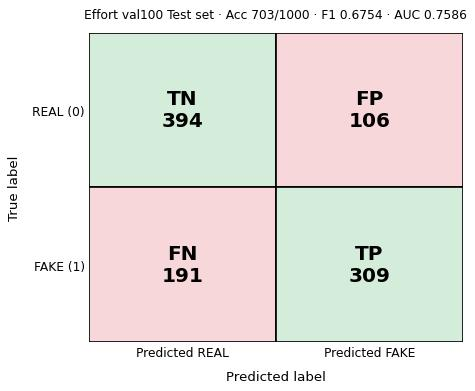

In [6]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, accuracy_score
from IPython.display import Image, display

THRESHOLD = 0.5

with open(OUT_RESULTS, "r") as f:
    results = json.load(f)

if len(results) == 0:
    raise RuntimeError("Result file is empty.")

y_true = np.array([int(r["true_label"]) for r in results])
y_score = np.array([float(r["score"]) for r in results])

# Check whether Effort score behaves like fake probability or real probability
auc_direct = roc_auc_score(y_true, y_score)
auc_inverted = roc_auc_score(y_true, 1.0 - y_score)

if auc_inverted > auc_direct:
    print("Score appears reversed. Using 1 - score as fake probability.")
    fake_score = 1.0 - y_score
    score_mode = "1 - score"
else:
    print("Score appears to be fake probability. Using score directly.")
    fake_score = y_score
    score_mode = "score"

y_pred = (fake_score >= THRESHOLD).astype(int)

f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, fake_score)
acc = accuracy_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
TN, FP, FN, TP = cm.ravel()

total = TP + TN + FP + FN
correct = TP + TN
wrong = FP + FN

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

print(f"Checkpoint epoch used: {results[0].get('checkpoint_epoch', 'unknown')}")
print(f"Checkpoint val AUC:    {results[0].get('checkpoint_val_auc', 'unknown')}")
print(f"Checkpoint val F1:     {results[0].get('checkpoint_val_f1', 'unknown')}")
print(f"Score mode used:       {score_mode}")
print()
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1:       {f1:.4f}")
print(f"Test AUC:      {auc:.4f}")
print(f"Result:        {correct}/{total}")
print(f"AUC direct:    {auc_direct:.4f}")
print(f"AUC inverted:  {auc_inverted:.4f}")

print(f"{'═'*44}")
print("  Confusion Matrix Results")
print(f"{'═'*44}")
print(f"  TP (fake correctly detected) : {TP}")
print(f"  TN (real correctly detected) : {TN}")
print(f"  FP (real wrongly called fake): {FP}")
print(f"  FN (fake wrongly called real): {FN}")
print(f"{'─'*44}")
print(f"  Precision(fake): {precision:.4f}")
print(f"  Recall(fake):    {recall:.4f}")
print(f"  Wrong:           {wrong}/{total}")

# Styled confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[TN, FP], [FN, TP]]
cell_colors = [
    ["#d4edda", "#f8d7da"],
    ["#f8d7da", "#d4edda"]
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i), 1, 1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5
            )
        )
        ax.text(
            j + 0.5,
            1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black"
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([1.5, 0.5])

ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["REAL (0)", "FAKE (1)"], fontsize=11)

ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    f"Effort val100 Test set · Acc {correct}/{total} · F1 {f1:.4f} · AUC {auc:.4f}",
    fontsize=11,
    pad=14
)

out_path = "/content/drive/MyDrive/Capstone_Hripsime/submission/results/figures/effort_3440_test_cm.jpg"

plt.tight_layout()
plt.savefig(
    out_path,
    dpi=80,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
plt.close(fig)

display(Image(out_path))

In [ ]:
# ── Badly / Well Detected — PublicTest — Effort, normal score only ──

%matplotlib inline

import os
import re
import json
import numpy as np
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display
from sklearn.metrics import roc_auc_score

THRESHOLD = 0.5

with open(OUT_RESULTS, "r") as f:
    results = json.load(f)

if len(results) == 0:
    raise RuntimeError("Test results file is empty.")

# ── Use normal Effort score directly as fake confidence ───────────────────────
y_true = np.array([int(r["true_label"]) for r in results])
raw_score = np.array([float(r["score"]) for r in results])

auc_direct = roc_auc_score(y_true, raw_score)
print("Using score directly as fake confidence.")
print(f"AUC direct: {auc_direct:.4f}")

# ── Rebuild confidence, predictions, and correct/wrong ────────────────────────
for r in results:
    confidence = float(r["score"])

    r["confidence"] = confidence
    r["pred"] = int(confidence >= THRESHOLD)
    r["correct"] = int(r["pred"]) == int(r["true_label"])

total = len(results)
n_correct = sum(r["correct"] for r in results)
accuracy = 100 * n_correct / total

well = [r for r in results if r["correct"]]
badly = [r for r in results if not r["correct"]]

well_sorted = sorted(well, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)
badly_sorted = sorted(badly, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)

well_sample = well_sorted[:50]
badly_sample = badly_sorted[:50]

n_real = sum(int(r["true_label"]) == 0 for r in results)
n_fake = sum(int(r["true_label"]) == 1 for r in results)

tp = sum((int(r["true_label"]) == 1 and int(r["pred"]) == 1) for r in results)
tn = sum((int(r["true_label"]) == 0 and int(r["pred"]) == 0) for r in results)
fp = sum((int(r["true_label"]) == 0 and int(r["pred"]) == 1) for r in results)
fn = sum((int(r["true_label"]) == 1 and int(r["pred"]) == 0) for r in results)

real_acc = 100 * tn / max(1, n_real)
fake_acc = 100 * tp / max(1, n_fake)
precision_fake = tp / max(1, tp + fp)
recall_fake = tp / max(1, tp + fn)
f1_fake = 2 * precision_fake * recall_fake / max(1e-12, precision_fake + recall_fake)

print(f"\nPublicTest: {n_correct}/{total} correct ({accuracy:.1f}% accuracy)")
print(f"REAL images: {n_real}  |  FAKE images: {n_fake}")
print(f"Well detected: {len(well)}  |  Badly detected: {len(badly)}")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"\nREAL accuracy: {real_acc:.2f}%")
print(f"FAKE accuracy: {fake_acc:.2f}%")
print(f"FAKE precision: {precision_fake:.4f}")
print(f"FAKE recall:    {recall_fake:.4f}")
print(f"FAKE F1:        {f1_fake:.4f}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def label_str(l):
    return "REAL" if int(l) == 0 else "FAKE"

def get_image_number(path):
    fname = os.path.basename(path)
    stem = os.path.splitext(fname)[0]

    if stem.isdigit():
        return stem

    m = re.search(r"\d+", stem)
    return m.group(0) if m else "unknown"

def load_thumb(path, size=128):
    img = PILImage.open(path).convert("RGB")
    w, h = img.size
    side = min(w, h)
    img = img.crop((
        (w - side) // 2,
        (h - side) // 2,
        (w + side) // 2,
        (h + side) // 2
    ))
    return img.resize((size, size), PILImage.LANCZOS)

def make_grid(samples, title, filename):
    n = len(samples)
    if n == 0:
        print(f"No samples to plot for {filename}")
        return

    cols = 10
    rows = max(1, (n + cols - 1) // cols)

    fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 3.6))
    fig.patch.set_facecolor("#1a1a1a")

    if rows == 1:
        flat_axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    else:
        flat_axes = axes.flatten()

    for idx, ax in enumerate(flat_axes):
        if idx >= n:
            ax.axis("off")
            continue

        r = samples[idx]

        try:
            ax.imshow(load_thumb(r["path"]))
        except Exception:
            ax.set_facecolor("#333")
            ax.text(
                0.5, 0.5, "error",
                ha="center", va="center",
                color="white", fontsize=7,
                transform=ax.transAxes
            )

        true_color = "#2ecc71" if int(r["true_label"]) == 0 else "#e74c3c"
        for spine in ax.spines.values():
            spine.set_edgecolor(true_color)
            spine.set_linewidth(3)

        ax.set_xticks([])
        ax.set_yticks([])

        img_num = get_image_number(r["path"])
        fname = os.path.basename(r["path"])

        ax.set_title(
            f"Image #{img_num}\n"
            f"{fname}\n"
            f"True: {label_str(r['true_label'])} → Pred: {label_str(r['pred'])}\n"
            f"fake conf: {r['confidence']:.3f}",
            fontsize=7,
            color="white",
            pad=8
        )

    for ax in flat_axes[n:]:
        ax.axis("off")

    real_p = mpatches.Patch(color="#2ecc71", label="True label: REAL")
    fake_p = mpatches.Patch(color="#e74c3c", label="True label: FAKE")
    fig.legend(
        handles=[real_p, fake_p],
        loc="lower center",
        ncol=2,
        fontsize=10,
        framealpha=0.3,
        facecolor="#333",
        labelcolor="white",
        bbox_to_anchor=(0.5, 0.005)
    )

    fig.suptitle(title, fontsize=14, color="white", fontweight="medium")
    plt.subplots_adjust(hspace=0.85, wspace=0.1, top=0.88, bottom=0.06)

    plt.savefig(
        filename,
        dpi=90,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )
    plt.close(fig)
    display(Image(filename))

# ── Plots ─────────────────────────────────────────────────────────────────────
make_grid(
    well_sample,
    title="50 most confidently CORRECT predictions — Effort PublicTest\n"
          "Border = true label",
    filename="effort_well_detected_test.jpg"
)

make_grid(
    badly_sample,
    title="50 most confidently WRONG predictions — Effort PublicTest\n"
          "Border = true label",
    filename="effort_badly_detected_test.jpg"
)

Using score directly as fake confidence.
AUC direct: 0.7563

PublicTest: 702/1000 correct (70.2% accuracy)
REAL images: 500  |  FAKE images: 500
Well detected: 702  |  Badly detected: 298
TP=309, TN=393, FP=107, FN=191

REAL accuracy: 78.60%
FAKE accuracy: 61.80%
FAKE precision: 0.7428
FAKE recall:    0.6180
FAKE F1:        0.6747


In [ ]:
# # ── Badly / Well Detected — Effort top 50 by confidence, grouped REAL / FAKE

# %matplotlib inline

# import os
# import re
# import json
# import numpy as np
# from PIL import Image as PILImage
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# from IPython.display import Image, display
# from sklearn.metrics import roc_auc_score

# THRESHOLD = 0.5

# with open(OUT_RESULTS, "r") as f:
#     results = json.load(f)

# if len(results) == 0:
#     raise RuntimeError("Test results file is empty.")

# y_true = np.array([int(r["true_label"]) for r in results])
# raw_score = np.array([float(r["score"]) for r in results])

# auc_direct = roc_auc_score(y_true, raw_score)
# print("Using score directly as fake confidence.")
# print(f"AUC direct: {auc_direct:.4f}")

# # ── Recompute confidence, prediction, and correctness ─────────────────────────
# for r in results:
#     confidence = float(r["score"])

#     r["confidence"] = confidence
#     r["pred"] = int(confidence >= THRESHOLD)
#     r["correct"] = int(r["pred"]) == int(r["true_label"])

# well = [r for r in results if r["correct"]]
# badly = [r for r in results if not r["correct"]]

# # 1) sort by confidence distance from 0.5
# well_sorted = sorted(well, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)
# badly_sorted = sorted(badly, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)

# # 2) take top 50 first
# well_top50 = well_sorted[:50]
# badly_top50 = badly_sorted[:50]

# # 3) then group REAL first, FAKE second, preserving order inside each label
# def group_real_fake(samples):
#     real_group = [r for r in samples if int(r["true_label"]) == 0]
#     fake_group = [r for r in samples if int(r["true_label"]) == 1]
#     return real_group + fake_group

# well_sample = group_real_fake(well_top50)
# badly_sample = group_real_fake(badly_top50)

# print(f"\nCorrect predictions: {len(well)}")
# print(f"Wrong predictions:   {len(badly)}")
# print(f"Showing correct top50 grouped: {len(well_sample)}")
# print(f"Showing wrong top50 grouped:   {len(badly_sample)}")

# def label_str(l):
#     return "REAL" if int(l) == 0 else "FAKE"

# def get_image_number(path):
#     fname = os.path.basename(path)
#     stem = os.path.splitext(fname)[0]

#     if stem.isdigit():
#         return stem

#     m = re.search(r"\d+", stem)
#     return m.group(0) if m else "unknown"

# def load_thumb(path, size=128):
#     img = PILImage.open(path).convert("RGB")
#     w, h = img.size
#     side = min(w, h)
#     img = img.crop((
#         (w - side) // 2,
#         (h - side) // 2,
#         (w + side) // 2,
#         (h + side) // 2
#     ))
#     return img.resize((size, size), PILImage.LANCZOS)

# def make_grid(samples, title, filename, cols=10):
#     n = len(samples)
#     if n == 0:
#         print(f"No samples to show for {filename}")
#         return

#     rows = (n + cols - 1) // cols
#     fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 3.6))
#     fig.patch.set_facecolor("#1a1a1a")

#     if rows == 1:
#         flat_axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
#     else:
#         flat_axes = axes.flatten()

#     for idx, ax in enumerate(flat_axes):
#         if idx >= n:
#             ax.axis("off")
#             continue

#         r = samples[idx]

#         try:
#             ax.imshow(load_thumb(r["path"]))
#         except Exception:
#             ax.set_facecolor("#333")
#             ax.text(
#                 0.5, 0.5, "error",
#                 ha="center", va="center",
#                 color="white", fontsize=7,
#                 transform=ax.transAxes
#             )

#         true_color = "#2ecc71" if int(r["true_label"]) == 0 else "#e74c3c"
#         for spine in ax.spines.values():
#             spine.set_edgecolor(true_color)
#             spine.set_linewidth(3)

#         ax.set_xticks([])
#         ax.set_yticks([])

#         fname = os.path.basename(r["path"])
#         img_num = get_image_number(r["path"])

#         ax.set_title(
#             f"Image #{img_num}\n"
#             f"{fname}\n"
#             f"{label_str(r['true_label'])} → {label_str(r['pred'])}\n"
#             f"fake conf: {r['confidence']:.3f}",
#             fontsize=7,
#             color="white",
#             pad=8
#         )

#     for ax in flat_axes[n:]:
#         ax.axis("off")

#     real_p = mpatches.Patch(color="#2ecc71", label="True label: REAL")
#     fake_p = mpatches.Patch(color="#e74c3c", label="True label: FAKE")
#     fig.legend(
#         handles=[real_p, fake_p],
#         loc="lower center",
#         ncol=2,
#         fontsize=10,
#         framealpha=0.3,
#         facecolor="#333",
#         labelcolor="white",
#         bbox_to_anchor=(0.5, 0.005)
#     )

#     fig.suptitle(title, fontsize=14, color="white", fontweight="medium")
#     plt.subplots_adjust(hspace=0.85, wspace=0.1, top=0.88, bottom=0.06)

#     plt.savefig(
#         filename,
#         dpi=90,
#         bbox_inches="tight",
#         facecolor=fig.get_facecolor()
#     )
#     plt.close(fig)

#     display(Image(filename))

# make_grid(
#     well_sample,
#     title="Effort — Correct predictions, top 50 by confidence, grouped REAL then FAKE",
#     filename="effort_well_detected_grouped.jpg"
# )

# make_grid(
#     badly_sample,
#     title="Effort — Wrong predictions, top 50 by confidence, grouped REAL then FAKE",
#     filename="effort_badly_detected_grouped.jpg"
# )

In [11]:
import nbformat
NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Effort 3440 Test.ipynb"

nb = nbformat.read(NOTEBOOK_PATH, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, NOTEBOOK_PATH)

In [12]:
!pip install nbconvert -q

NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Effort 3440 Test.ipynb"
OUTPUT_DIR    = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks"

!jupyter nbconvert \
    --to html \
    --embed-images \
    --output-dir "{OUTPUT_DIR}" \
    "{NOTEBOOK_PATH}"

print("Done — check your Drive for the .html file")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Effort 3440 Test.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 604992 bytes to /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks/Effort 3440 Test.html
Done — check your Drive for the .html file
